# Data Introduction

In [1]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import warnings
from IPython.display import display

In [2]:
# In this cell, we will employ the pandas library to read the file.

# Read the original CSV file
df = pd.read_csv("Crime_Data_from_2020_to_Present.csv")

# Display the dataset
display(df.head())
display(df.tail())

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,...,Status,Status Desc,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LOCATION,Cross Street,LAT,LON
0,190326475,3/1/2020 0:00,3/1/2020 0:00,2130,7,Wilshire,784,1,510,VEHICLE - STOLEN,...,AA,Adult Arrest,510.0,998.0,NaN,NaN,1900 S LONGWOOD AV,NaN,34.0375,-118.3506
1,200106753,2/9/2020 0:00,2/8/2020 0:00,1800,1,Central,182,1,330,BURGLARY FROM VEHICLE,...,IC,Invest Cont,330.0,998.0,NaN,NaN,1000 S FLOWER ST,NaN,34.0444,-118.2628
2,200320258,11/11/2020 0:00,11/4/2020 0:00,1700,3,Southwest,356,1,480,BIKE - STOLEN,...,IC,Invest Cont,480.0,NaN,NaN,NaN,1400 W 37TH ST,NaN,34.0210,-118.3002
3,200907217,5/10/2023 0:00,3/10/2020 0:00,2037,9,Van Nuys,964,1,343,SHOPLIFTING-GRAND THEFT ($950.01 & OVER),...,IC,Invest Cont,343.0,NaN,NaN,NaN,14000 RIVERSIDE DR,NaN,34.1576,-118.4387
4,200412582,9/9/2020 0:00,9/9/2020 0:00,630,4,Hollenbeck,413,1,510,VEHICLE - STOLEN,...,IC,Invest Cont,510.0,NaN,NaN,NaN,200 E AVENUE 28,NaN,34.0820,-118.2130


,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,...,Status,Status Desc,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LOCATION,Cross Street,LAT,LON
1005193,250304214,2/23/2025 0:00,2/21/2025 0:00,1530,3,Southwest,358,1,510,VEHICLE - STOLEN,...,IC,Invest Cont,510.0,NaN,NaN,NaN,3600 MCCLINTOCK AV,NaN,34.0212,-118.2895
1005194,250304203,2/20/2025 0:00,2/13/2025 0:00,2100,3,Southwest,325,1,522,"VEHICLE, STOLEN - OTHER (MOTORIZED SCOOTERS, B...",...,IC,Invest Cont,522.0,NaN,NaN,NaN,2600 ELLENDALE PL,NaN,34.0307,-118.2923
1005195,250504051,1/14/2025 0:00,1/14/2025 0:00,1250,5,Harbor,509,1,210,ROBBERY,...,IC,Invest Cont,210.0,NaN,NaN,NaN,24300 WESTERN AV,NaN,33.8046,-118.3074
1005196,251604136,2/27/2025 0:00,2/27/2025 0:00,1550,16,Foothill,1664,1,510,VEHICLE - STOLEN,...,AA,Adult Arrest,510.0,NaN,NaN,NaN,11900 SHELDON ST,NaN,34.2404,-118.3922
1005197,251904210,3/25/2025 0:00,3/25/2025 0:00,1235,19,Mission,1944,2,850,INDECENT EXPOSURE,...,IC,Invest Cont,850.0,NaN,NaN,NaN,11100 OMELVENY AV,NaN,34.2722,-118.4417


In [3]:
# In this step, we will carefully examine the dataset to identify any inconsistencies or instances of missing values.
display(df.info())
print("Number of rows: ",len(df.index))
print("Number of columns: ", len(df.columns))

# Check for columns with missing data
null_columns = df.columns[df.isna().any()]

# printing columns names containing null values if any
print("columns that contain missing data: ", list(null_columns))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1005198 entries, 0 to 1005197
Data columns (total 28 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   DR_NO           1005198 non-null  int64  
 1   Date Rptd       1005198 non-null  object 
 2   DATE OCC        1005198 non-null  object 
 3   TIME OCC        1005198 non-null  int64  
 4   AREA            1005198 non-null  int64  
 5   AREA NAME       1005198 non-null  object 
 6   Rpt Dist No     1005198 non-null  int64  
 7   Part 1-2        1005198 non-null  int64  
 8   Crm Cd          1005198 non-null  int64  
 9   Crm Cd Desc     1005198 non-null  object 
 10  Mocodes         853438 non-null   object 
 11  Vict Age        1005198 non-null  int64  
 12  Vict Sex        860416 non-null   object 
 13  Vict Descent    860404 non-null   object 
 14  Premis Cd       1005182 non-null  float64
 15  Premis Desc     1004610 non-null  object 
 16  Weapon Used Cd  327280 non-null   fl

None

Number of rows:  1005198
Number of columns:  28
columns that contain missing data:  ['Mocodes', 'Vict Sex', 'Vict Descent', 'Premis Cd', 'Premis Desc', 'Weapon Used Cd', 'Weapon Desc', 'Status', 'Crm Cd 1', 'Crm Cd 2', 'Crm Cd 3', 'Crm Cd 4', 'Cross Street']


### Dataset Columns Description

| Column Name       | Description                                                                 |
|-------------------|-----------------------------------------------------------------------------|
| DR_NO             | A Unique Identifier of the crime report                                     |
| Date Rptd         | The Date the crime was reported                                              |
| DATE OCC          | The actual date the crime occurred                                           |
| TIME OCC          | The time the crime occurred, in a 24h format                                 |
| AREA              | The numeric code representing the geographical area where the crime occurred|
| AREA NAME         | Name of the geographical area (same as AREA)                                 |
| Rpt Dist No       | Reporting district number for the incident                                   |
| Part 1-2          | Crime classification (part 1: serious crime, part 2: less serious crime)     |
| Crm Cd            | Numeric code representing the crime type                                     |
| Crm Cd Desc       | Description of the crime type                                                |
| Mocodes           | Modus Operandi codes, describing the method used in the crime                |
| Vict Age          | Age of the victim                                                            |
| Vict Sex          | Gender of the victim                                                         |
| Vict Descent      | Ethnicity or descent of the victim                                           |
| Premis Cd         | Numeric code for the type of premises where the crime occurred               |
| Premis Desc       | Description of the premises                                                  |
| Weapon Used Cd    | Numeric code of the weapon used in the crime, if applicable                  |
| Weapon Desc       | Description of the weapon used                                               |
| Status            | Status code of the crime case                                                |
| Status Desc       | Description of the case status                                               |
| Crm Cd 1          | Additional crime code, if incident involved multiple offenses                |
| Crm Cd 2          | Additional crime code, if incident involved multiple offenses                |
| Crm Cd 3          | Additional crime code, if incident involved multiple offenses                |
| Crm Cd 4          | Additional crime code, if incident involved multiple offenses                |
| LOCATION          | Text description of the crime location                                       |
| Cross Street      | Nearby cross street for the crime location                                   |
| LAT               | Latitude of the crime location                                               |
| LON               | Longitude of the crime location

In [4]:
# Identify the number of unique values in each column
df.nunique()

DR_NO             1005198
Date Rptd            1906
DATE OCC             1901
TIME OCC             1439
AREA                   21
AREA NAME              21
Rpt Dist No          1210
Part 1-2                2
Crm Cd                140
Crm Cd Desc           140
Mocodes            310956
Vict Age              104
Vict Sex                5
Vict Descent           20
Premis Cd             314
Premis Desc           306
Weapon Used Cd         79
Weapon Desc            79
Status                  6
Status Desc             6
Crm Cd 1              142
Crm Cd 2              126
Crm Cd 3               38
Crm Cd 4                6
LOCATION            66567
Cross Street        10414
LAT                  5426
LON                  4982
dtype: int64

___

# Data Cleaning

In [5]:
# Checking for duplicates
df.drop_duplicates(inplace=True)

In [6]:
# Check for inconsistencies and handle them

# Trimming whitespace
string_columns = df.select_dtypes(include='object').columns
df[string_columns] = df[string_columns].apply(lambda x: x.str.strip())
display(df.head())

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,...,Status,Status Desc,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LOCATION,Cross Street,LAT,LON
0,190326475,3/1/2020 0:00,3/1/2020 0:00,2130,7,Wilshire,784,1,510,VEHICLE - STOLEN,...,AA,Adult Arrest,510.0,998.0,NaN,NaN,1900 S LONGWOOD AV,NaN,34.0375,-118.3506
1,200106753,2/9/2020 0:00,2/8/2020 0:00,1800,1,Central,182,1,330,BURGLARY FROM VEHICLE,...,IC,Invest Cont,330.0,998.0,NaN,NaN,1000 S FLOWER ST,NaN,34.0444,-118.2628
2,200320258,11/11/2020 0:00,11/4/2020 0:00,1700,3,Southwest,356,1,480,BIKE - STOLEN,...,IC,Invest Cont,480.0,NaN,NaN,NaN,1400 W 37TH ST,NaN,34.0210,-118.3002
3,200907217,5/10/2023 0:00,3/10/2020 0:00,2037,9,Van Nuys,964,1,343,SHOPLIFTING-GRAND THEFT ($950.01 & OVER),...,IC,Invest Cont,343.0,NaN,NaN,NaN,14000 RIVERSIDE DR,NaN,34.1576,-118.4387
4,200412582,9/9/2020 0:00,9/9/2020 0:00,630,4,Hollenbeck,413,1,510,VEHICLE - STOLEN,...,IC,Invest Cont,510.0,NaN,NaN,NaN,200 E AVENUE 28,NaN,34.0820,-118.2130


In [7]:
# Sort the dataset based on the incident report time
df = df.sort_values(by='DATE OCC')

In [8]:
# for numeric data:
df.describe()

,DR_NO,TIME OCC,AREA,Rpt Dist No,Part 1-2,Crm Cd,Vict Age,Premis Cd,Weapon Used Cd,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LAT,LON
count,1.005198e+06,1.005198e+06,1.005198e+06,1.005198e+06,1.005198e+06,1.005198e+06,1.005198e+06,1.005182e+06,327280.000000,1.005187e+06,69159.000000,2314.000000,64.00000,1.005198e+06,1.005198e+06
mean,2.202277e+08,1.339911e+03,1.069098e+01,1.115556e+03,1.400283e+00,5.001458e+02,2.891253e+01,3.056189e+02,363.953651,4.999063e+02,958.105221,984.015990,991.21875,3.399820e+01,-1.180909e+02
std,1.320282e+07,6.510531e+02,6.110385e+00,6.111733e+02,4.899559e-01,2.052635e+02,2.199382e+01,2.193160e+02,123.736081,2.050640e+02,110.354136,52.350982,27.06985,1.610549e+00,5.581812e+00
min,8.170000e+02,1.000000e+00,1.000000e+00,1.010000e+02,1.000000e+00,1.100000e+02,-4.000000e+00,1.010000e+02,101.000000,1.100000e+02,210.000000,310.000000,821.00000,0.000000e+00,-1.186676e+02
25%,2.106169e+08,9.000000e+02,5.000000e+00,5.870000e+02,1.000000e+00,3.310000e+02,0.000000e+00,1.010000e+02,311.000000,3.310000e+02,998.000000,998.000000,998.00000,3.401470e+01,-1.184305e+02
50%,2.209160e+08,1.420000e+03,1.100000e+01,1.139000e+03,1.000000e+00,4.420000e+02,3.000000e+01,2.030000e+02,400.000000,4.420000e+02,998.000000,998.000000,998.00000,3.405890e+01,-1.183225e+02
75%,2.311105e+08,1.900000e+03,1.600000e+01,1.613000e+03,2.000000e+00,6.260000e+02,4.400000e+01,5.010000e+02,400.000000,6.260000e+02,998.000000,998.000000,998.00000,3.416490e+01,-1.182739e+02
max,2.521041e+08,2.359000e+03,2.100000e+01,2.199000e+03,2.000000e+00,9.560000e+02,1.200000e+02,9.760000e+02,516.000000,9.560000e+02,999.000000,999.000000,999.00000,3.433430e+01,0.000000e+00


In [9]:
# for categorical data:
df.describe(include=['object'])

,Date Rptd,DATE OCC,AREA NAME,Crm Cd Desc,Mocodes,Vict Sex,Vict Descent,Premis Desc,Weapon Desc,Status,Status Desc,LOCATION,Cross Street
count,1005198,1005198,1005198,1005198,853438,860416,860404,1004610,327280,1005197,1005198,1005198,154243
unique,1906,1901,21,140,310956,5,20,306,79,6,6,66567,10414
top,2/2/2023 0:00,1/1/2020 0:00,Central,VEHICLE - STOLEN,344,M,H,STREET,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",IC,Invest Cont,800 N ALAMEDA ST,BROADWAY
freq,929,1164,69674,115247,42200,403916,296437,261389,174777,803946,803946,2598,2487


In [10]:
# i will go over the number of null values in each column and row:
print("number of nulls in each column:\n",df.isnull().sum())
print("\n\nnumber of nulls in each row: \n",df.isnull().sum(axis=1))


number of nulls in each column:
 DR_NO                   0
Date Rptd               0
DATE OCC                0
TIME OCC                0
AREA                    0
AREA NAME               0
Rpt Dist No             0
Part 1-2                0
Crm Cd                  0
Crm Cd Desc             0
Mocodes            151760
Vict Age                0
Vict Sex           144782
Vict Descent       144794
Premis Cd              16
Premis Desc           588
Weapon Used Cd     677918
Weapon Desc        677918
Status                  1
Status Desc             0
Crm Cd 1               11
Crm Cd 2           936039
Crm Cd 3          1002884
Crm Cd 4          1005134
LOCATION                0
Cross Street       850955
LAT                     0
LON                     0
dtype: int64


number of nulls in each row: 
 94783     4
149713    6
77287     3
141139    6
8462      2
         ..
886667    6
897919    9
949153    6
878756    6
950960    9
Length: 1005198, dtype: int64


In [11]:
# From the description of the data and the number of null values in each column, I decided to drop the following columns. 
# These columns are not related to the purpose of this study at this time
df = df.drop(['DR_NO', 'Weapon Used Cd', 'Crm Cd 2', 'Crm Cd 3', 'Crm Cd 4', 'LOCATION', 'Cross Street',
              'Weapon Desc', 'Mocodes'], axis=1)
display(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 1005198 entries, 94783 to 950960
Data columns (total 19 columns):
 #   Column        Non-Null Count    Dtype  
---  ------        --------------    -----  
 0   Date Rptd     1005198 non-null  object 
 1   DATE OCC      1005198 non-null  object 
 2   TIME OCC      1005198 non-null  int64  
 3   AREA          1005198 non-null  int64  
 4   AREA NAME     1005198 non-null  object 
 5   Rpt Dist No   1005198 non-null  int64  
 6   Part 1-2      1005198 non-null  int64  
 7   Crm Cd        1005198 non-null  int64  
 8   Crm Cd Desc   1005198 non-null  object 
 9   Vict Age      1005198 non-null  int64  
 10  Vict Sex      860416 non-null   object 
 11  Vict Descent  860404 non-null   object 
 12  Premis Cd     1005182 non-null  float64
 13  Premis Desc   1004610 non-null  object 
 14  Status        1005197 non-null  object 
 15  Status Desc   1005198 non-null  object 
 16  Crm Cd 1      1005187 non-null  float64
 17  LAT           1005198 non-nul

None

In [12]:
# Here, I will check the number of null values in each row after deletig the columns above
# This steps help in deciding the limit to where we should delete rows with certain number of null values
count = (df.isnull().sum(axis=1) > 1).sum()
print("Number of rows with more than 1 null values:", count)
count = (df.isnull().sum(axis=1) > 2).sum()
print("Number of rows with more than 2 null values:", count)

Number of rows with more than 1 null values: 144778
Number of rows with more than 2 null values: 17


In [13]:
# since the time format is in 2400 format, I will convert it to only hours so that it will be easier to use later for visualiztion and training
df['TIME OCC'] = df['TIME OCC'] // 100

In [14]:
# checking the dataset:
df.head()

,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,Vict Age,Vict Sex,Vict Descent,Premis Cd,Premis Desc,Status,Status Desc,Crm Cd 1,LAT,LON
94783,1/1/2020 0:00,1/1/2020 0:00,18,6,Hollywood,646,2,624,BATTERY - SIMPLE ASSAULT,55,M,H,210.0,RESTAURANT/FAST FOOD,IC,Invest Cont,624.0,34.0980,-118.3332
149713,1/7/2020 0:00,1/1/2020 0:00,12,18,Southeast,1802,2,354,THEFT OF IDENTITY,19,F,H,501.0,SINGLE FAMILY DWELLING,IC,Invest Cont,354.0,33.9556,-118.2739
77287,1/1/2020 0:00,1/1/2020 0:00,12,1,Central,157,1,230,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",57,M,B,102.0,SIDEWALK,IC,Invest Cont,230.0,34.0401,-118.2459
141139,1/2/2020 0:00,1/1/2020 0:00,20,18,Southeast,1863,1,420,THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER),37,F,H,101.0,STREET,IC,Invest Cont,420.0,33.9237,-118.2681
8462,1/2/2020 0:00,1/1/2020 0:00,17,11,Northeast,1105,1,210,ROBBERY,61,M,W,108.0,PARKING LOT,AA,Adult Arrest,210.0,34.1442,-118.2180


In [15]:
# since the date is the essence in this project, 
# I will convert the date and time to different column for illustration and modelling purposes
# Note: the main focus here based on the time of the incident (not the report)

df['Date Rptd'] = pd.to_datetime(df['Date Rptd'].str.split().str[0], format='%m/%d/%Y')
df['DATE OCC'] = pd.to_datetime(df['DATE OCC'].str.split().str[0], format='%m/%d/%Y')

# Here, i tried to find the time difference between the incident time and the report time
df['report_delay_days'] = (df['Date Rptd'] - df['DATE OCC']).dt.days

In [16]:
display(df['report_delay_days'])

94783     0
149713    6
77287     0
141139    1
8462      1
         ..
886667    0
897919    6
949153    0
878756    2
950960    2
Name: report_delay_days, Length: 1005198, dtype: int64

In [17]:
# since we have a column of the report delay, I will drop the rows that has more than 10 days delay:
df = df[df["report_delay_days"] <= 10]

In [18]:
# working on the DATE OCC (as it is the independence variable in this study)

df['week day'] = df['DATE OCC'].dt.day_name()
df['day'] = df['DATE OCC'].dt.day
df['month'] = df['DATE OCC'].dt.month
df['year'] = df['DATE OCC'].dt.year


In [19]:
df.head()

,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,Vict Age,...,Status,Status Desc,Crm Cd 1,LAT,LON,report_delay_days,week day,day,month,year
94783,2020-01-01,2020-01-01,18,6,Hollywood,646,2,624,BATTERY - SIMPLE ASSAULT,55,...,IC,Invest Cont,624.0,34.0980,-118.3332,0,Wednesday,1,1,2020
149713,2020-01-07,2020-01-01,12,18,Southeast,1802,2,354,THEFT OF IDENTITY,19,...,IC,Invest Cont,354.0,33.9556,-118.2739,6,Wednesday,1,1,2020
77287,2020-01-01,2020-01-01,12,1,Central,157,1,230,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",57,...,IC,Invest Cont,230.0,34.0401,-118.2459,0,Wednesday,1,1,2020
141139,2020-01-02,2020-01-01,20,18,Southeast,1863,1,420,THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER),37,...,IC,Invest Cont,420.0,33.9237,-118.2681,1,Wednesday,1,1,2020
8462,2020-01-02,2020-01-01,17,11,Northeast,1105,1,210,ROBBERY,61,...,AA,Adult Arrest,210.0,34.1442,-118.2180,1,Wednesday,1,1,2020


In [20]:
# checking the new columns
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 894553 entries, 94783 to 950960
Data columns (total 24 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   Date Rptd          894553 non-null  datetime64[ns]
 1   DATE OCC           894553 non-null  datetime64[ns]
 2   TIME OCC           894553 non-null  int64         
 3   AREA               894553 non-null  int64         
 4   AREA NAME          894553 non-null  object        
 5   Rpt Dist No        894553 non-null  int64         
 6   Part 1-2           894553 non-null  int64         
 7   Crm Cd             894553 non-null  int64         
 8   Crm Cd Desc        894553 non-null  object        
 9   Vict Age           894553 non-null  int64         
 10  Vict Sex           761680 non-null  object        
 11  Vict Descent       761669 non-null  object        
 12  Premis Cd          894539 non-null  float64       
 13  Premis Desc        893994 non-null  object   

## Filling the missing values:

In [21]:
count = (df.isnull().sum(axis=1) > 1).sum()
print("Number of rows with more than 1 null values:", count)
count = (df.isnull().sum(axis=1) > 2).sum()
print("Number of rows with more than 2 null values:", count)
count = (df.isnull().sum(axis=1) > 3).sum()
print("Number of rows with more than 3 null values:", count)

Number of rows with more than 1 null values: 132869
Number of rows with more than 2 null values: 15
Number of rows with more than 3 null values: 13


In [22]:
# drop the rows with more than 3 null values:
df = df.dropna(thresh=df.shape[1] - 3)

In [23]:
# we have sex and descent victims columns are incomplete, and from the data plot we did earlier, I noticed that some age values are in zero

# fill in the age column with the median for now, although my predictive model doesn't need me to predict the 
# age of the victim or the criminal but it will help for the after analysis

df['Vict Age'] = df['Vict Age'].replace(0, np.nan)
df['Vict Age'] = df['Vict Age'].fillna(df['Vict Age'].median())

# and for status discription:
df['Status Desc'] = df['Status Desc'].str.strip().str.title()

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 894540 entries, 94783 to 950960
Data columns (total 24 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   Date Rptd          894540 non-null  datetime64[ns]
 1   DATE OCC           894540 non-null  datetime64[ns]
 2   TIME OCC           894540 non-null  int64         
 3   AREA               894540 non-null  int64         
 4   AREA NAME          894540 non-null  object        
 5   Rpt Dist No        894540 non-null  int64         
 6   Part 1-2           894540 non-null  int64         
 7   Crm Cd             894540 non-null  int64         
 8   Crm Cd Desc        894540 non-null  object        
 9   Vict Age           894540 non-null  float64       
 10  Vict Sex           761680 non-null  object        
 11  Vict Descent       761669 non-null  object        
 12  Premis Cd          894539 non-null  float64       
 13  Premis Desc        893994 non-null  object   

In [25]:
# Victim Sex:
df['Vict Sex'] = df['Vict Sex'].str.strip().str.upper()
sex_map = {'M': 'Male', 'F': 'Female', 'X': 'Unknown'}

# replace the values with its full name
df['Vict Sex'] = df['Vict Sex'].map(sex_map).fillna(df['Vict Sex'])


In [26]:
# printing the values of sex column and prepare it to fill
print(df['Vict Sex'].unique())
df['Vict Sex'] = df['Vict Sex'].replace({'H': np.nan, '-': np.nan})
print(df['Vict Sex'].unique())

['Male' 'Female' 'Unknown' nan 'H' '-']
['Male' 'Female' 'Unknown' nan]


In [27]:
# fill missing value in victim sex column:
mode_value = df['Vict Sex'].mode()[0]  # Get the mode (most common value)
df['Vict Sex'] = df['Vict Sex'].fillna(mode_value)

In [28]:
# Victim Descent:
df['Vict Descent'] = df['Vict Descent'].str.strip().str.upper()

# identify missing values
print(df['Vict Descent'].unique())
df['Vict Descent'] = df['Vict Descent'].replace('-', np.nan)
print(df['Vict Descent'].unique())


['H' 'B' 'W' 'X' 'O' nan 'A' 'F' 'K' 'C' 'J' 'U' 'V' 'Z' 'I' 'S' 'L' 'D'
 'P' 'G' '-']
['H' 'B' 'W' 'X' 'O' nan 'A' 'F' 'K' 'C' 'J' 'U' 'V' 'Z' 'I' 'S' 'L' 'D'
 'P' 'G']


In [29]:
# Victim Descent:
descent_map = {
    "A": "Other Asian",
    "B": "Black",
    "C": "Chinese",
    "D": "Cambodian/Laotian",
    "F": "Filipino",
    "G": "Guamanian",
    "H": "Hispanic/Latino",
    "I": "American Indian/Alaskan",
    "J": "Japanese",
    "K": "Korean",
    "L": "Cambodian",
    "O": "Other",
    "P": "Pacific Islander",
    "S": "Samoan",
    "U": "Hawaiian",
    "V": "Vietnamese",
    "W": "White",
    "X": "Unknown",
    "Z": "Asian Indian",
    "-": "Invalid or Missing"
}


# replace the values with its full name
df['Vict Descent'] = df['Vict Descent'].map(descent_map).fillna(df['Vict Descent'])


#### List of the coded Vict Descent (according to LAPD):

| Code | Full Description           |
|:-----|:--------------------------|
| A    | Other Asian               |
| B    | Black                     |
| C    | Chinese                   |
| D    | Cambodian/Laotian         |
| F    | Filipino                  |
| G    | Guamanian                 |
| H    | Hispanic/Latino           |
| I    | American Indian/Alaskan   |
| J    | Japanese                  |
| K    | Korean                    |
| L    | Cambodian                 |
| O    | Other                     |
| P    | Pacific Islander          |
| S    | Samoan                    |
| U    | Hawaiian                  |
| V    | Vietnamese                |
| W    | White                     |
| X    | Unknown                   |
| Z    | Asian Indian              |
| -    | Invalid or Missing        |

In [30]:
df.head()

,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,Vict Age,...,Status,Status Desc,Crm Cd 1,LAT,LON,report_delay_days,week day,day,month,year
94783,2020-01-01,2020-01-01,18,6,Hollywood,646,2,624,BATTERY - SIMPLE ASSAULT,55.0,...,IC,Invest Cont,624.0,34.0980,-118.3332,0,Wednesday,1,1,2020
149713,2020-01-07,2020-01-01,12,18,Southeast,1802,2,354,THEFT OF IDENTITY,19.0,...,IC,Invest Cont,354.0,33.9556,-118.2739,6,Wednesday,1,1,2020
77287,2020-01-01,2020-01-01,12,1,Central,157,1,230,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",57.0,...,IC,Invest Cont,230.0,34.0401,-118.2459,0,Wednesday,1,1,2020
141139,2020-01-02,2020-01-01,20,18,Southeast,1863,1,420,THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER),37.0,...,IC,Invest Cont,420.0,33.9237,-118.2681,1,Wednesday,1,1,2020
8462,2020-01-02,2020-01-01,17,11,Northeast,1105,1,210,ROBBERY,61.0,...,AA,Adult Arrest,210.0,34.1442,-118.2180,1,Wednesday,1,1,2020


---

# Create a new dataframe (crime count)
This is an important step to prepare the data for modeling

In [31]:
# make a new dataframe to count the dates and each crime they are committed in:
crime_count_df = df.groupby('DATE OCC').size().reset_index(name='crime count')

crime_count_df.rename(columns={'DATE OCC': 'crime date'}, inplace=True)
crime_count_df


,crime date,crime count
0,2020-01-01,562
1,2020-01-02,452
2,2020-01-03,508
3,2020-01-04,491
4,2020-01-05,470
...,...,...
1893,2025-03-21,2
1894,2025-03-24,1
1895,2025-03-25,2
1896,2025-03-26,2


In [32]:
crime_count_df = crime_count_df[crime_count_df['crime date'] < '2025-01-01']

In [33]:
crime_count_df

,crime date,crime count
0,2020-01-01,562
1,2020-01-02,452
2,2020-01-03,508
3,2020-01-04,491
4,2020-01-05,470
...,...,...
1821,2024-12-26,82
1822,2024-12-27,77
1823,2024-12-28,94
1824,2024-12-29,57


In [34]:
crime_count_df.describe()

,crime date,crime count
count,1826,1826.000000
mean,2022-07-01 12:00:00,489.742059
min,2020-01-01 00:00:00,7.000000
25%,2021-04-01 06:00:00,459.000000
50%,2022-07-01 12:00:00,515.000000
75%,2023-09-30 18:00:00,561.000000
max,2024-12-30 00:00:00,987.000000
std,NaN,122.911541


In [35]:
crime_count_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1826 entries, 0 to 1825
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   crime date   1826 non-null   datetime64[ns]
 1   crime count  1826 non-null   int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 42.8 KB


In [36]:
# save the new dataframe
crime_count_df.to_csv('crime_count_df.csv', index=False)

In [37]:
# read the new dataframe
crime_count_df = pd.read_csv("crime_count_df.csv")
crime_count_df['crime date'] = pd.to_datetime(crime_count_df['crime date'])  # convert to datetime
crime_count_df.set_index('crime date', inplace=True)           # make date the index
crime_count_df = crime_count_df.asfreq('D')                              # ensure daily frequency

# Check for missing dates (NaNs may appear if any days are missing)
crime_count_df = crime_count_df.fillna(0)
warnings.filterwarnings('ignore')

---

# Data Visualization

In [38]:
# making a copy of the crime count dataframe for visualization purposes:
crime_count_df_copy = crime_count_df.copy()
crime_count_df_copy = crime_count_df_copy.reset_index()

In [39]:
crime_count_df_copy

,crime date,crime count
0,2020-01-01,562
1,2020-01-02,452
2,2020-01-03,508
3,2020-01-04,491
4,2020-01-05,470
...,...,...
1821,2024-12-26,82
1822,2024-12-27,77
1823,2024-12-28,94
1824,2024-12-29,57


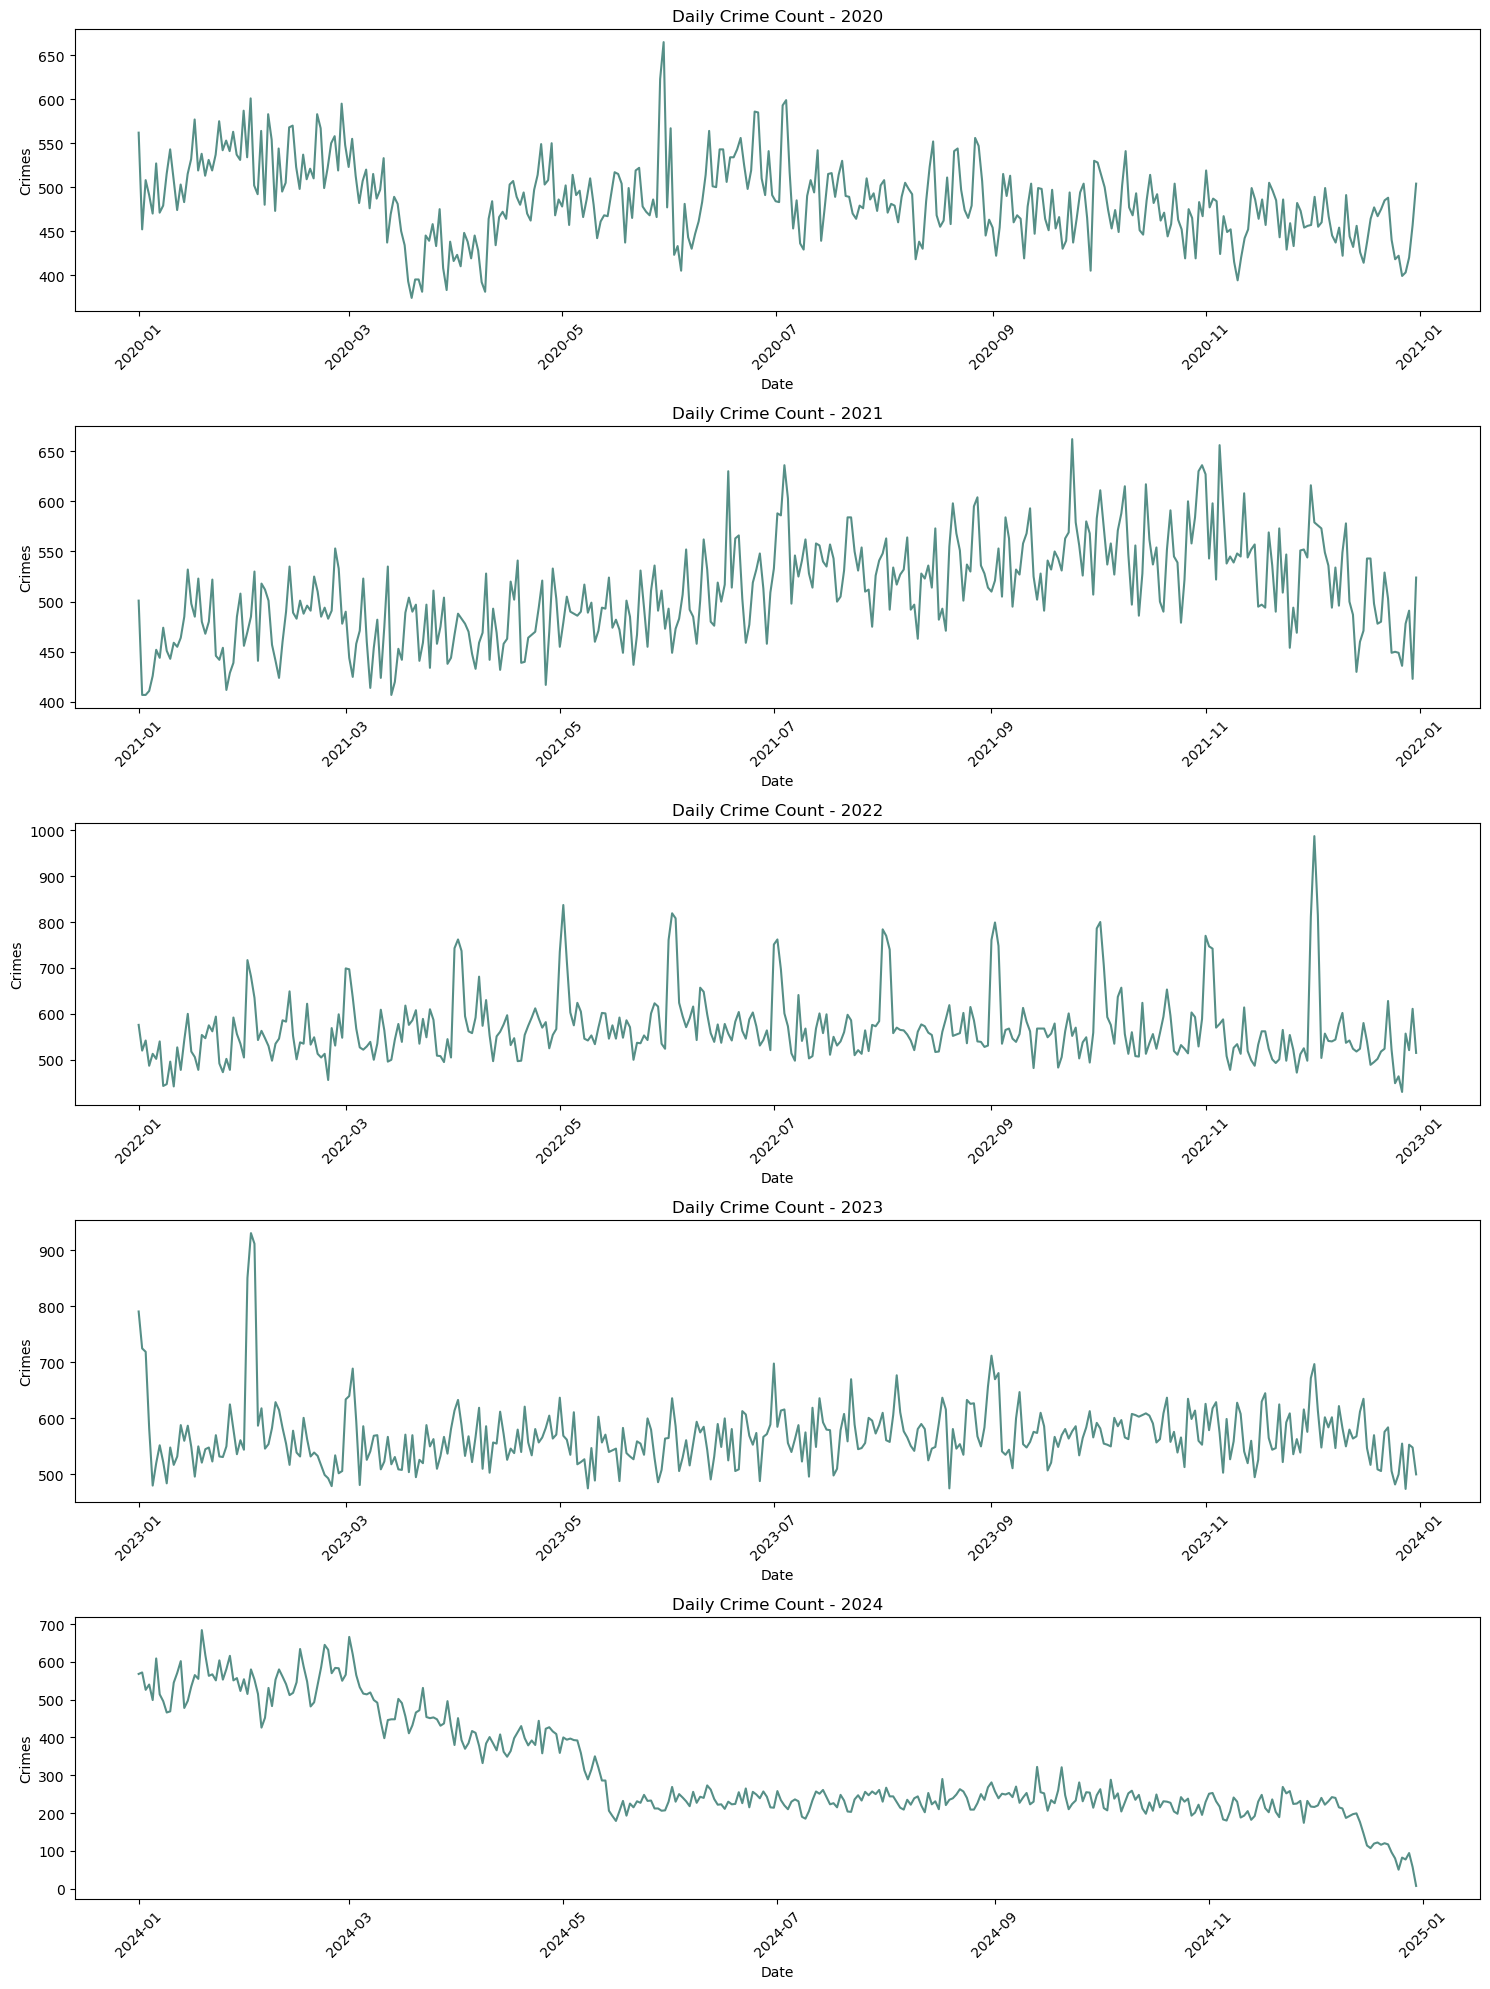

In [40]:
# make 5 plots for each year
crime_count_df_copy['year'] = crime_count_df_copy['crime date'].dt.year
years = list(range(2020, 2025))

fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(15, 20), sharex=False)

# Loop through each year and plot
for i, year in enumerate(years):
    ax = axes[i]
    yearly_data = crime_count_df_copy[crime_count_df_copy['year'] == year]
    sns.lineplot(data=yearly_data, x='crime date', y='crime count', ax=ax, color='#568F87')
    ax.set_title(f'Daily Crime Count - {year}')
    ax.set_ylabel('Crimes')
    ax.set_xlabel('Date')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [41]:
# now for each month (from 2020 to 2025):
crime_count_df_copy['month'] = crime_count_df_copy['crime date'].dt.month_name()
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

monthly_totals = crime_count_df_copy.groupby('month')['crime count'].sum().reindex(month_order)

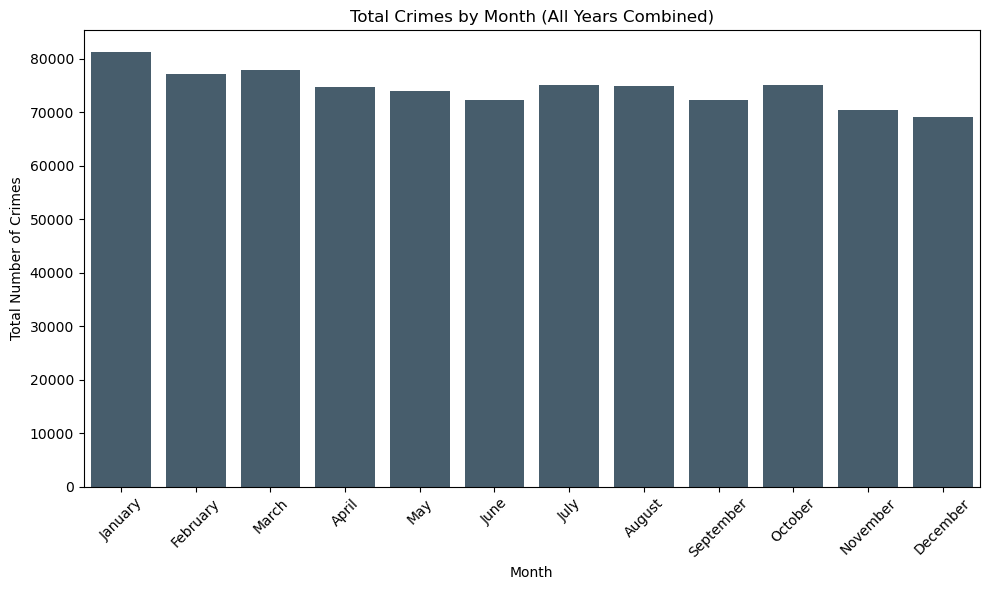

In [42]:
# plot the number of crimes per month (for all 5 years):
plt.figure(figsize=(10, 6))
sns.barplot(x=monthly_totals.index, y=monthly_totals.values, color='#415E72')
plt.title('Total Crimes by Month (All Years Combined)')
plt.xlabel('Month')
plt.ylabel('Total Number of Crimes')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

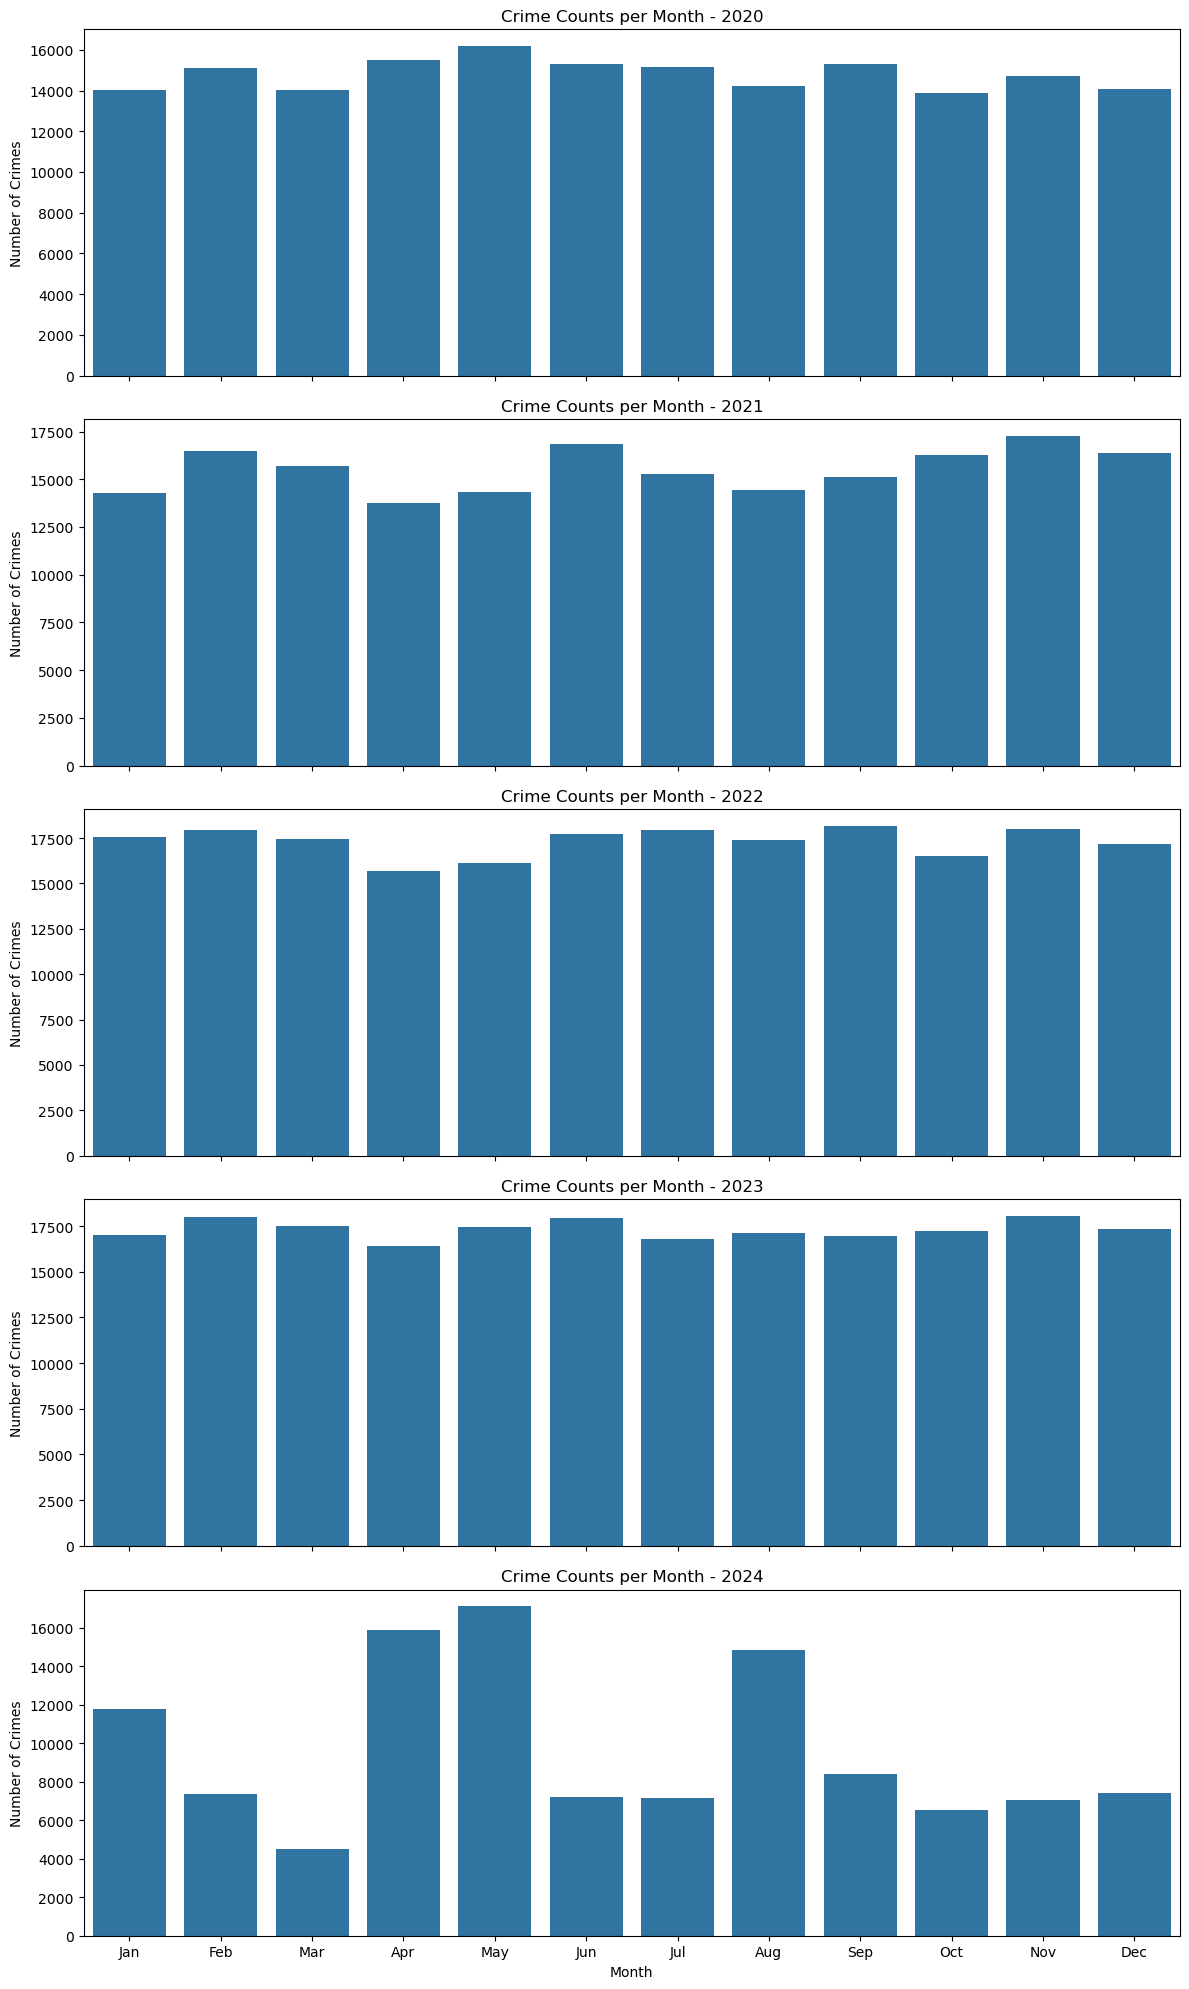

In [43]:
# here, a histplot that represent the crime count per month in each single year
# Group by year and month, summing crime counts
monthly_counts = (crime_count_df_copy
    .groupby(['year', 'month'])['crime count']
    .sum()
    .reset_index()
)

years = sorted(monthly_counts['year'].unique())
fig, axes = plt.subplots(nrows=len(years), ncols=1, figsize=(12, 20), sharex=True)

for i, year in enumerate(years):
    ax = axes[i]
    yearly_data = monthly_counts[monthly_counts['year'] == year]
    sns.barplot(
        data=yearly_data,
        x='month',
        y='crime count',
        ax=ax
    )
    ax.set_title(f'Crime Counts per Month - {year}')
    ax.set_xlabel('Month')
    ax.set_ylabel('Number of Crimes')
    ax.set_xticks(range(0, 12))
    ax.set_xticklabels(
        ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
         'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    )

plt.tight_layout()
plt.show()

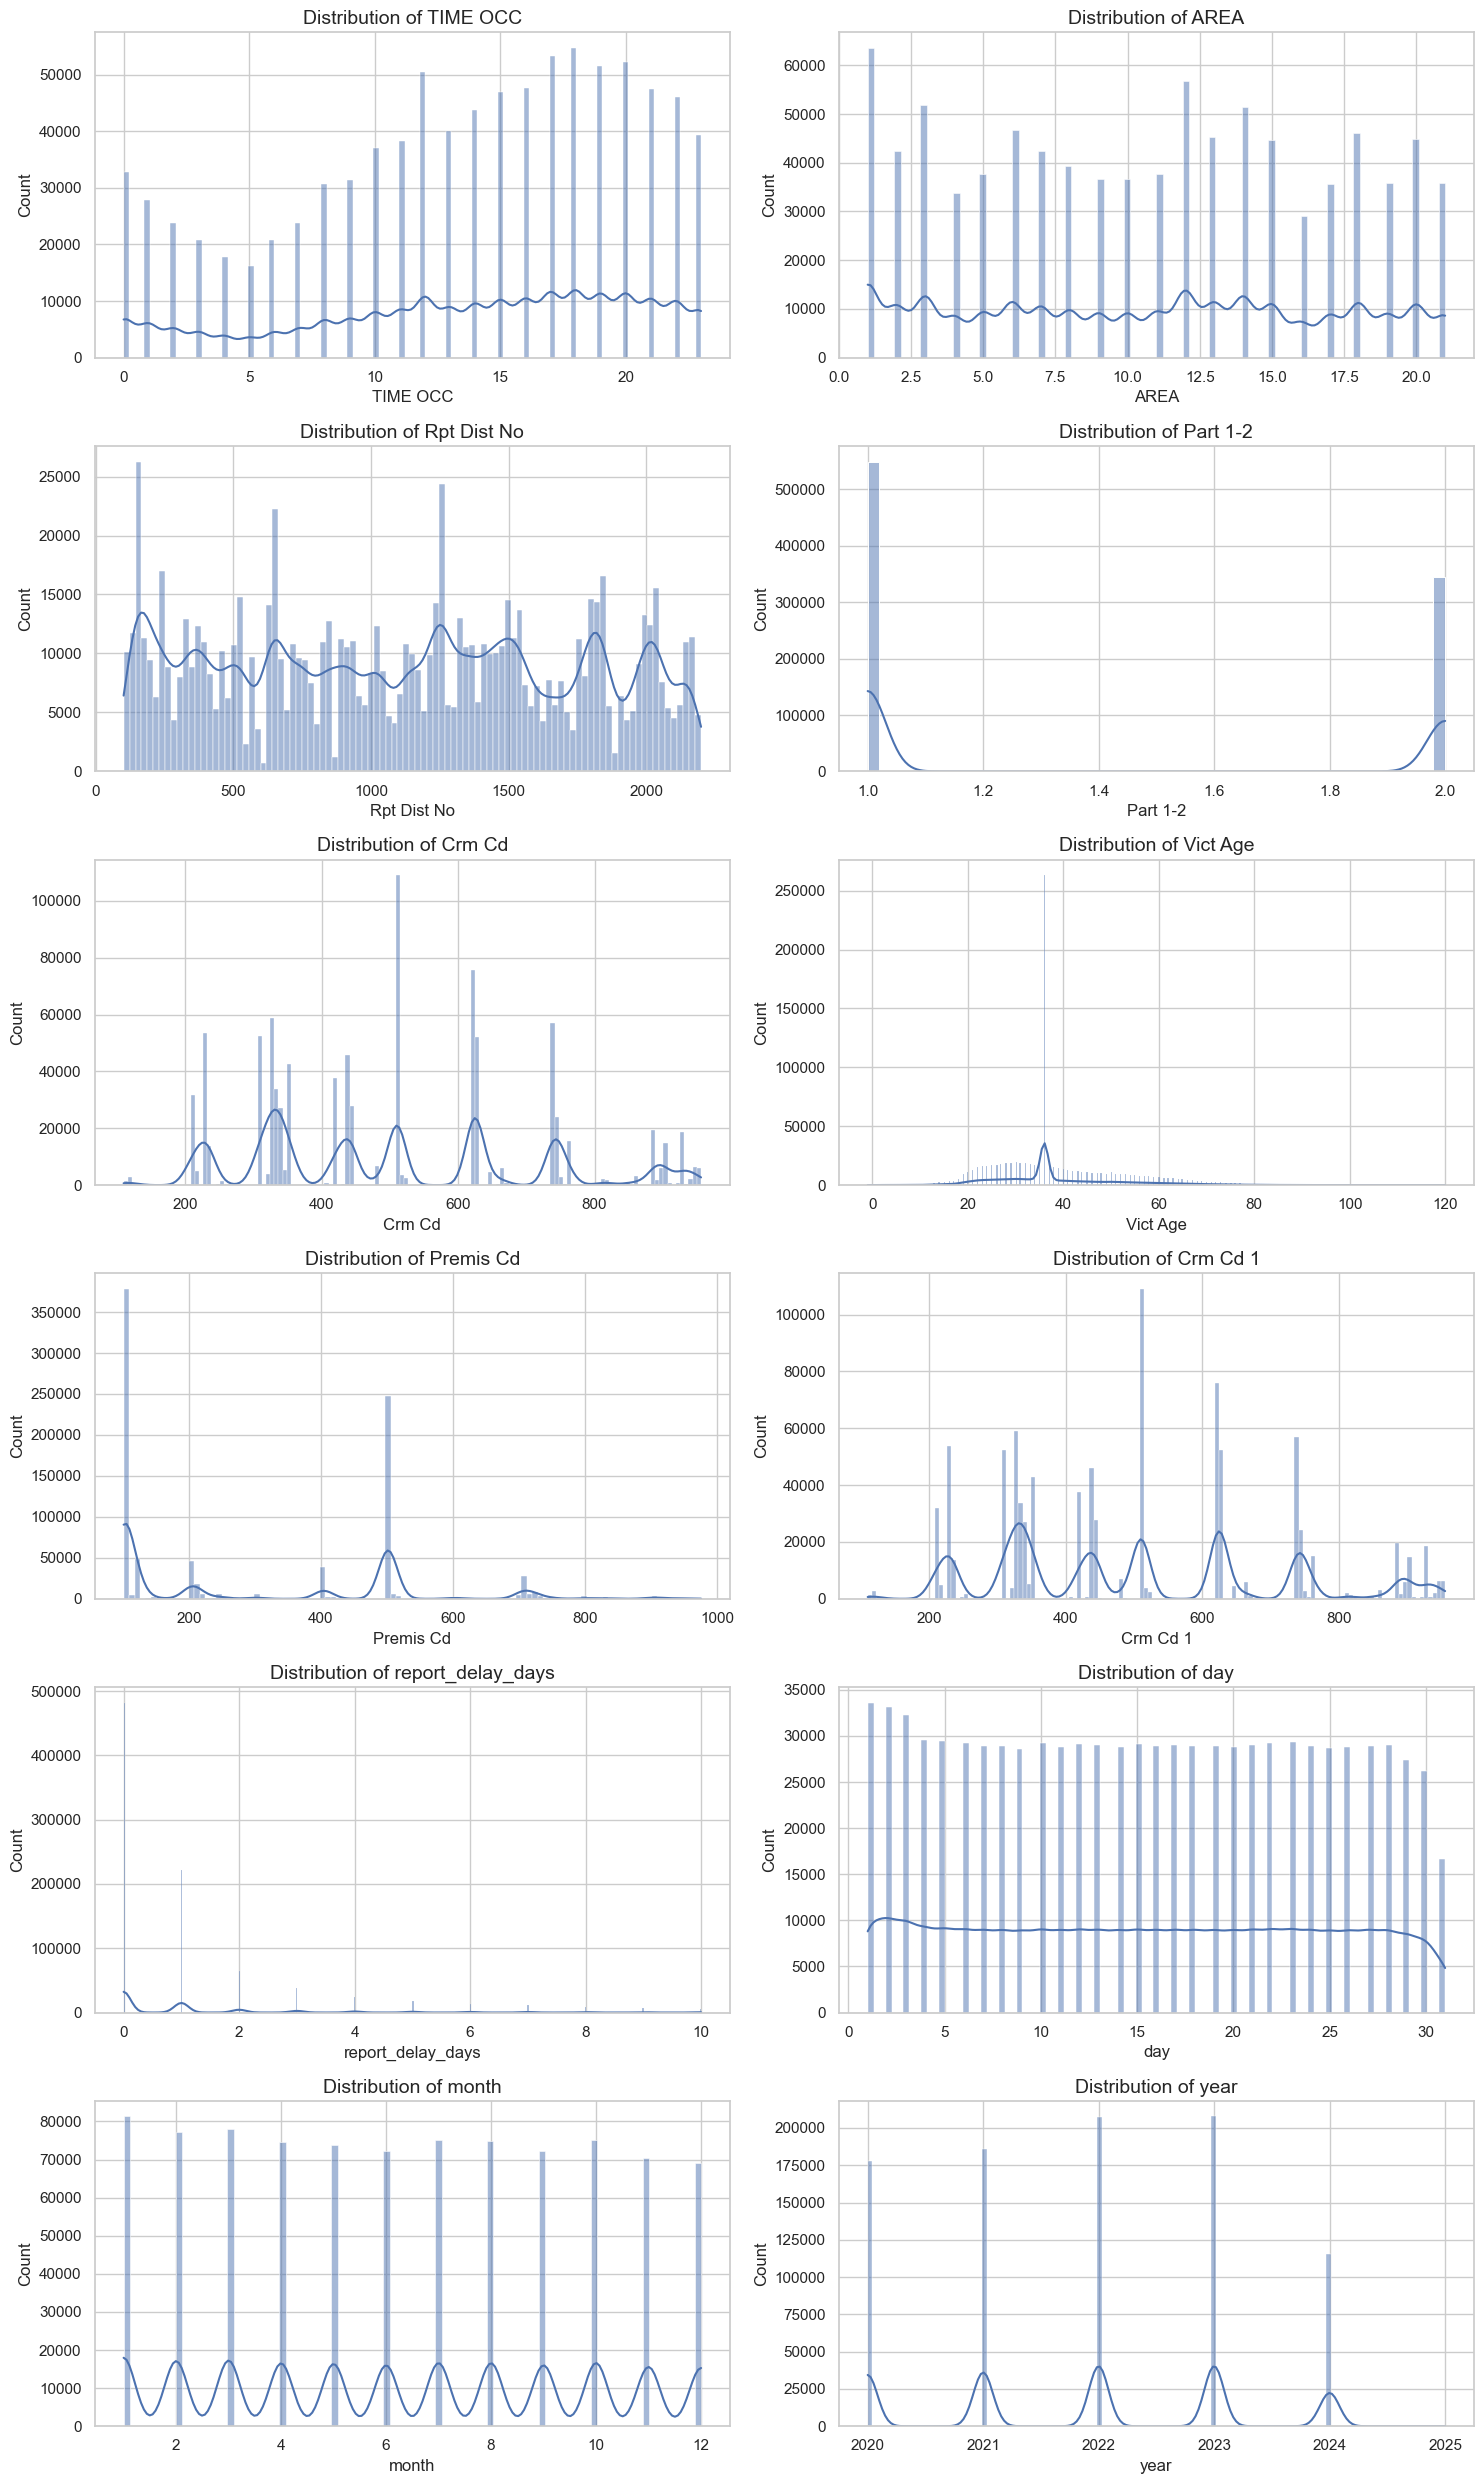

In [44]:
# Setting the aesthetics for the plots
sns.set(style="whitegrid")

# Preparing for univariate plots for some selected numerical and categorical columns
fig, axes = plt.subplots(nrows=6, ncols=2, figsize=(15, 25))
numerical_columns = pd.Index(["TIME OCC", "AREA", "Rpt Dist No", "Part 1-2", 
                              "Crm Cd", "Vict Age", "Premis Cd", "Crm Cd 1",
                             "report_delay_days", "day", "month", "year"])


# Plotting histograms for numerical columns
for i, col in enumerate(numerical_columns):
    sns.histplot(df[col], kde=True, ax=axes.flatten()[i])
    axes.flatten()[i].set_title(f'Distribution of {col}', fontsize=14)

plt.tight_layout()
plt.show()

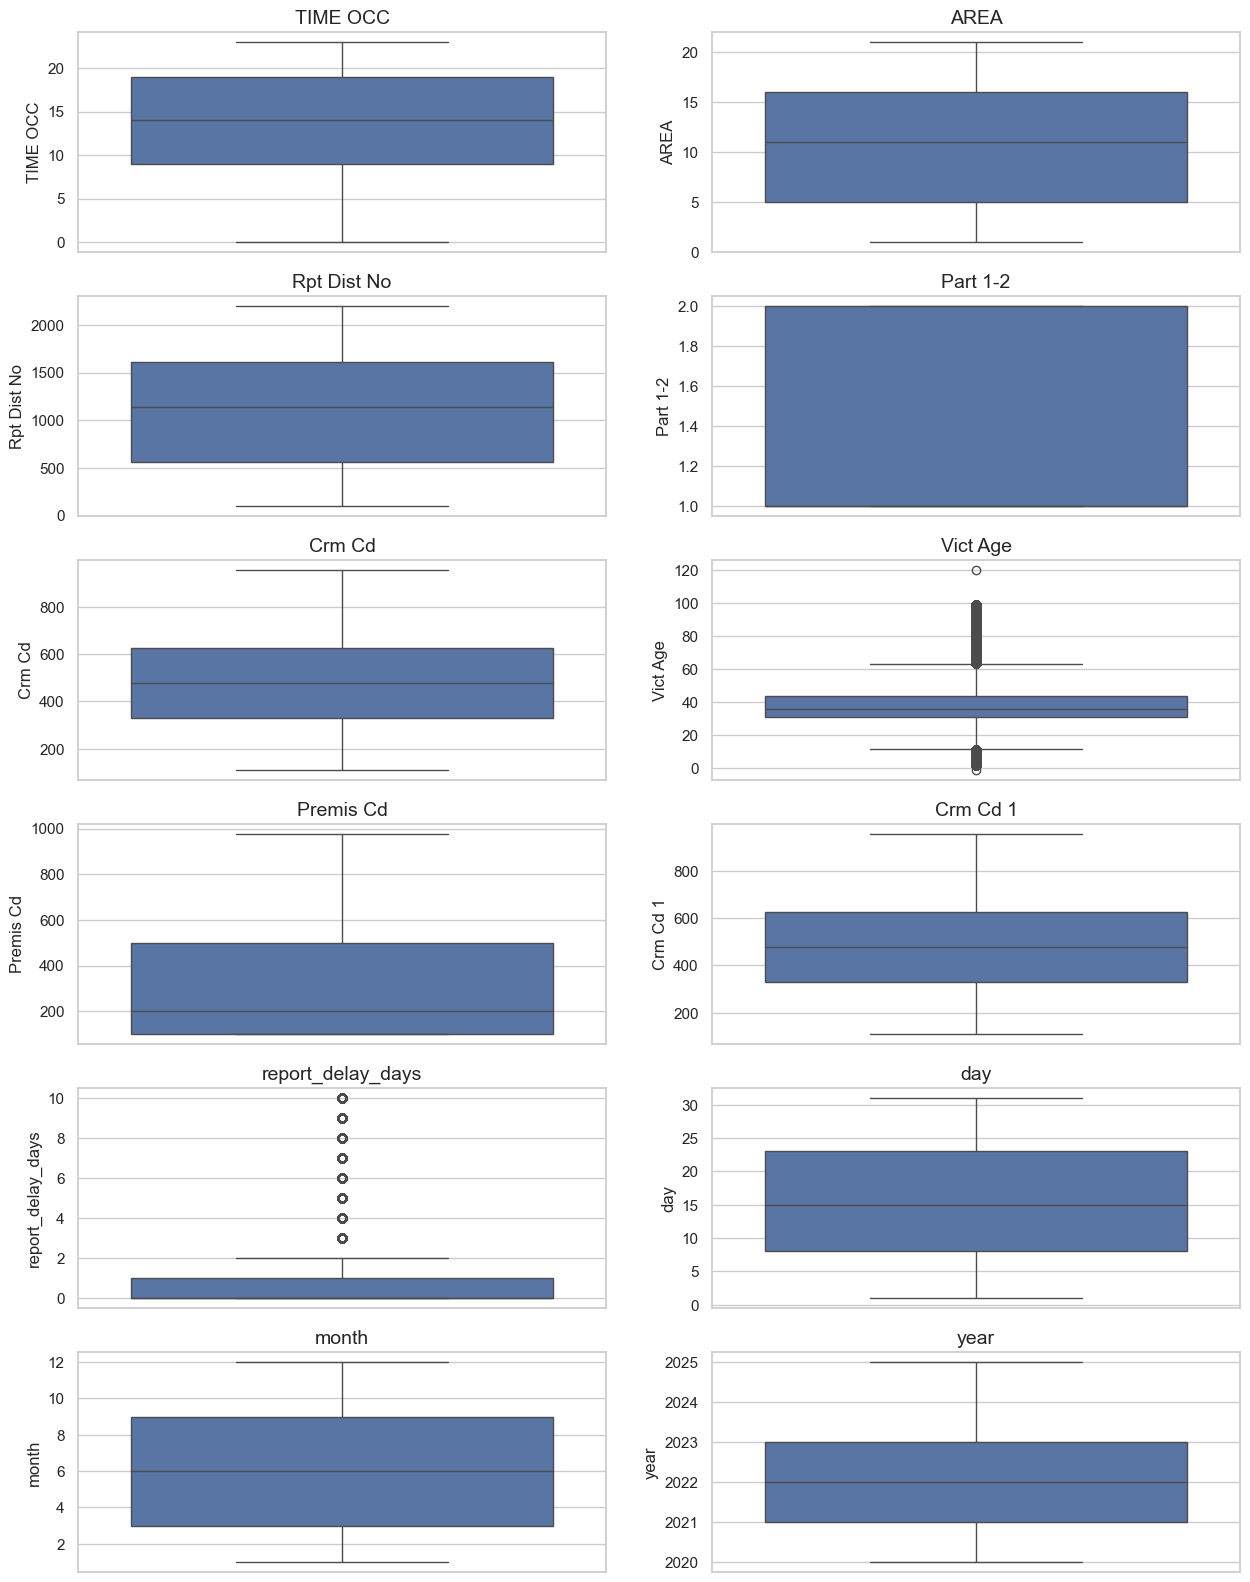

In [45]:
# detecting outliers in the dataset by box plot:
numerical_columns = pd.Index(["TIME OCC", "AREA", "Rpt Dist No", "Part 1-2", 
                              "Crm Cd", "Vict Age", "Premis Cd", "Crm Cd 1",
                             "report_delay_days", "day", "month", "year"])
fig, axes = plt.subplots(nrows=6, ncols=2, figsize=(15, 20))
sns.set(style="whitegrid")

for i, col in enumerate(numerical_columns):
    sns.boxplot(df[col], ax=axes.flatten()[i])
    axes.flatten()[i].set_title(f'{col}', fontsize=14)

plt.show()

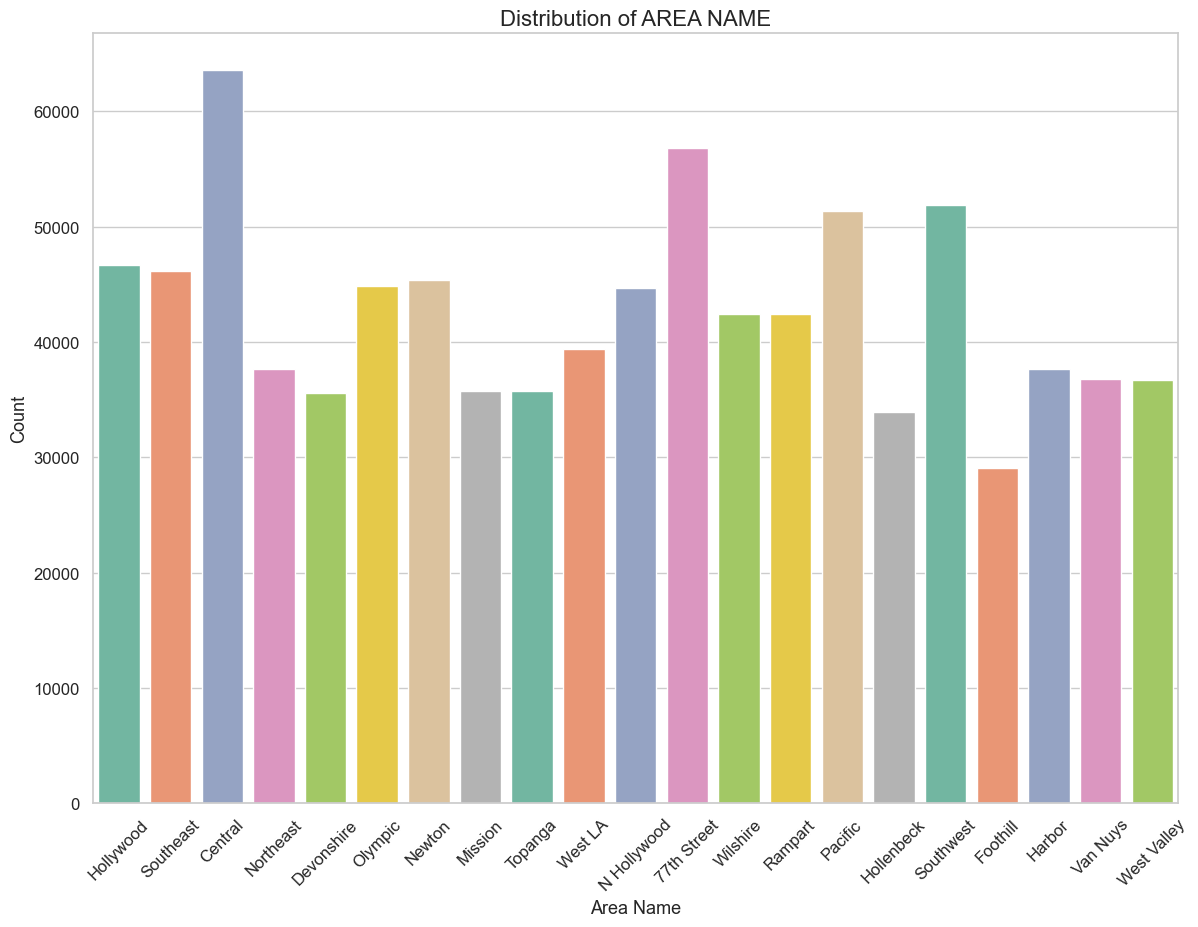

In [46]:
# catergorical data:

plt.figure(figsize=(14,10))
sns.countplot(x="AREA NAME", data=df, palette="Set2")
plt.title("Distribution of AREA NAME", fontsize=16)
plt.xlabel("Area Name", fontsize=13)
plt.ylabel("Count", fontsize=13)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.show()

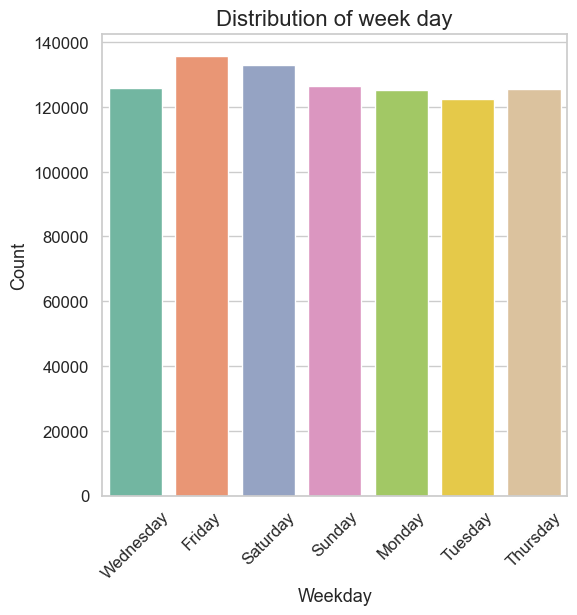

In [47]:
# catergorical data:

plt.figure(figsize=(6,6))
sns.countplot(x="week day", data=df, palette="Set2")
plt.title("Distribution of week day", fontsize=16)
plt.xlabel("Weekday", fontsize=13)
plt.ylabel("Count", fontsize=13)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.show()

In [48]:
# grouped:
def group_others(series, top_n=5):
    counts = series.value_counts()
    top = counts.nlargest(top_n)
    others_sum = counts.iloc[top_n:].sum()
    other_series = pd.Series({'Other': others_sum})
    grouped = pd.concat([top, other_series])
    return grouped

def autopct_conditional(pct, allvals, threshold=5):
    absolute = int(round(pct / 100. * sum(allvals)))
    # Show percent only if greater than threshold
    return f'{pct:.1f}%' if pct > threshold else ''


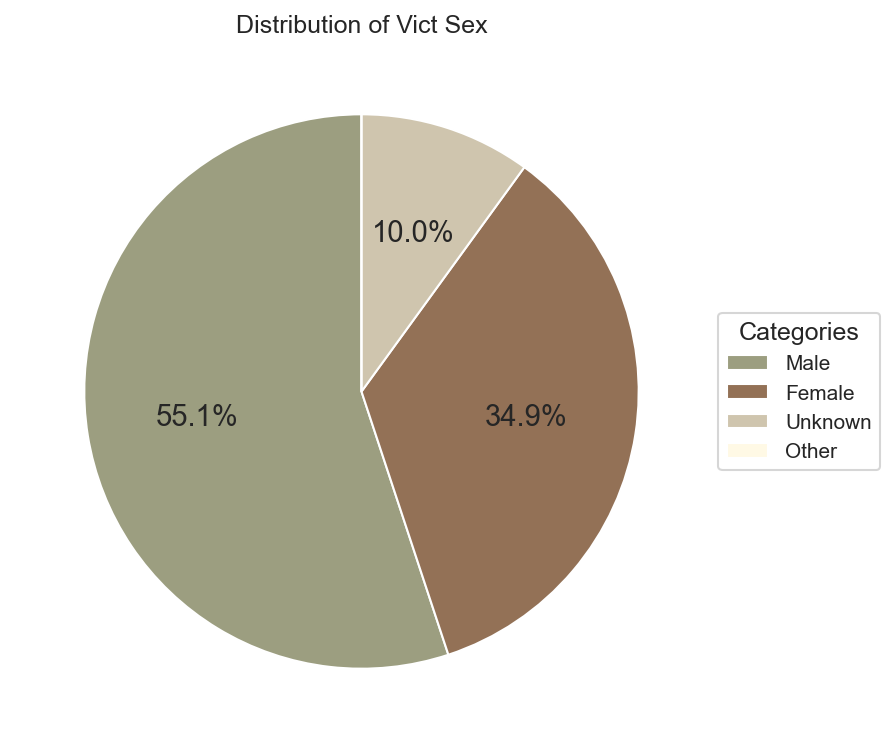

In [49]:
# Vict Sex
col = "Vict Sex"
data_grouped = group_others(df[col], top_n=4)

fig, ax = plt.subplots(figsize=(6,6), dpi=150)
wedges, texts, autotexts = ax.pie(
    data_grouped,
    labels=None,  # Hide default labels on slices
    autopct=lambda pct: autopct_conditional(pct, data_grouped),
    startangle=90,
    colors=['#9c9e80', '#937156', '#cfc5ae', '#FFF9E5']
)
for autotext in autotexts:
    autotext.set_fontsize(14)

# Add a legend with labels and corresponding colors
ax.legend(
    wedges, 
    data_grouped.index,
    title="Categories",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1),
    fontsize=10
)

plt.title(f'Distribution of {col}')
plt.show()


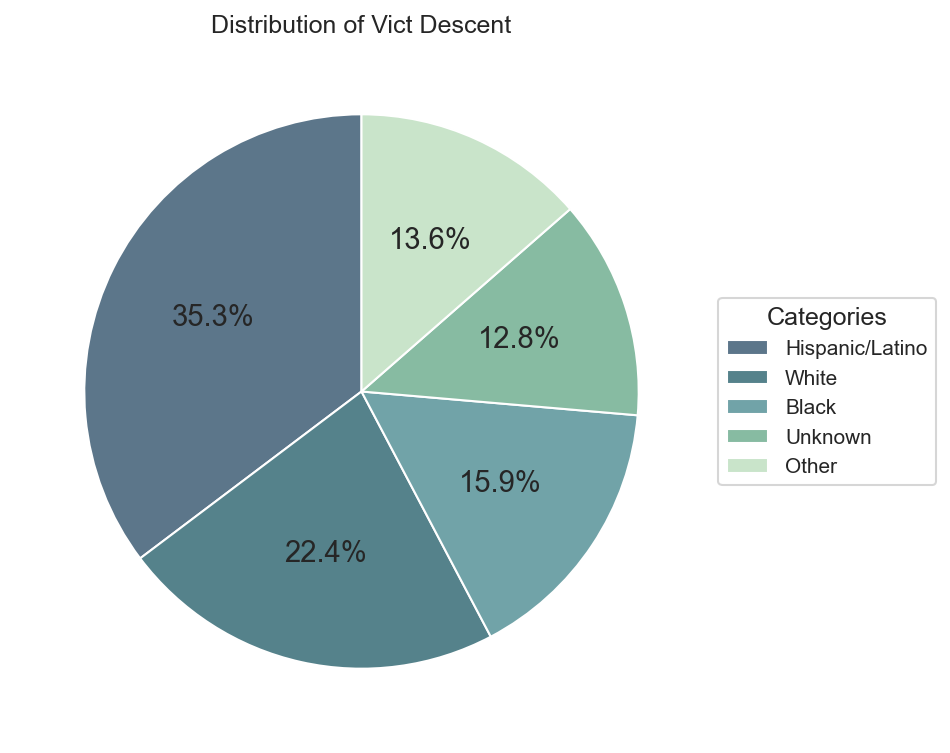

In [50]:
# Vict Descent

col = "Vict Descent"
data_grouped = group_others(df[col], top_n=4)

fig, ax = plt.subplots(figsize=(6,6), dpi=150)
wedges, texts, autotexts = ax.pie(
    data_grouped,
    labels=None,  # Hide default labels on slices
    autopct=lambda pct: autopct_conditional(pct, data_grouped),
    startangle=90,
    colors= ['#5c768a',  '#55828b', '#71a3a8','#87bba2', '#c9e4ca']
)
for autotext in autotexts:
    autotext.set_fontsize(14)

# Add a legend with labels and corresponding colors
ax.legend(
    wedges, 
    data_grouped.index,
    title="Categories",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1),
    fontsize=10
)

plt.title(f'Distribution of {col}')
plt.show()



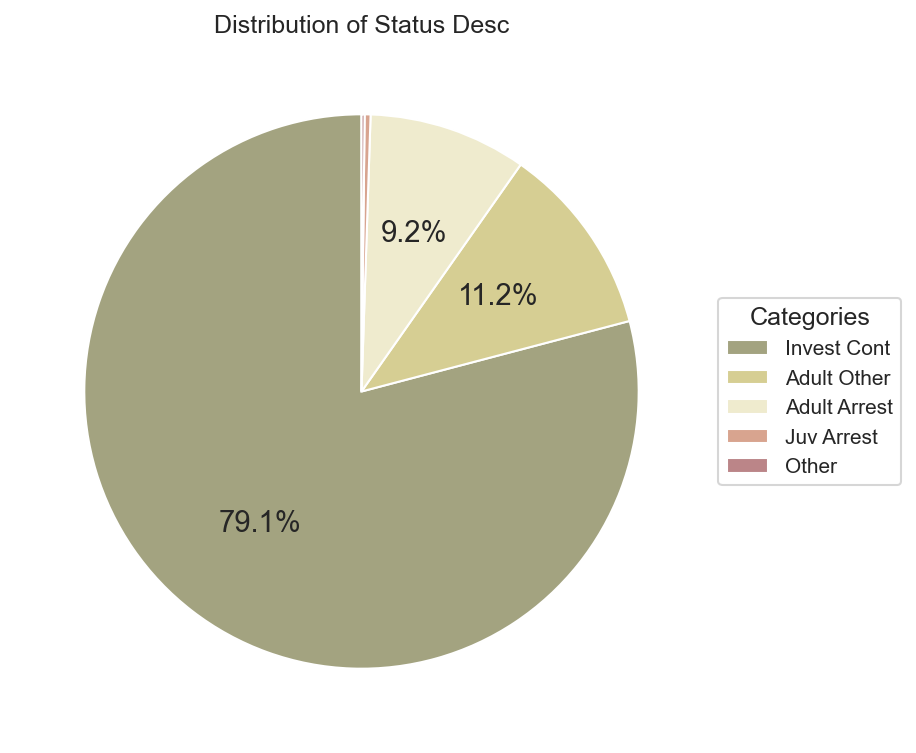

In [51]:
# Status Desc

col = "Status Desc"
data_grouped = group_others(df[col], top_n=4)

fig, ax = plt.subplots(figsize=(6,6), dpi=150)
wedges, texts, autotexts = ax.pie(
    data_grouped,
    labels=None,  # Hide default labels on slices
    autopct=lambda pct: autopct_conditional(pct, data_grouped),
    startangle=90,
    colors= [ '#a3a380', '#d6ce93','#efebce','#d8a48f', '#bb8588'  ]
)
for autotext in autotexts:
    autotext.set_fontsize(14)
# Add a legend with labels and corresponding colors
ax.legend(
    wedges, 
    data_grouped.index,
    title="Categories",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1),
    fontsize=10
)

plt.title(f'Distribution of {col}')
plt.show()


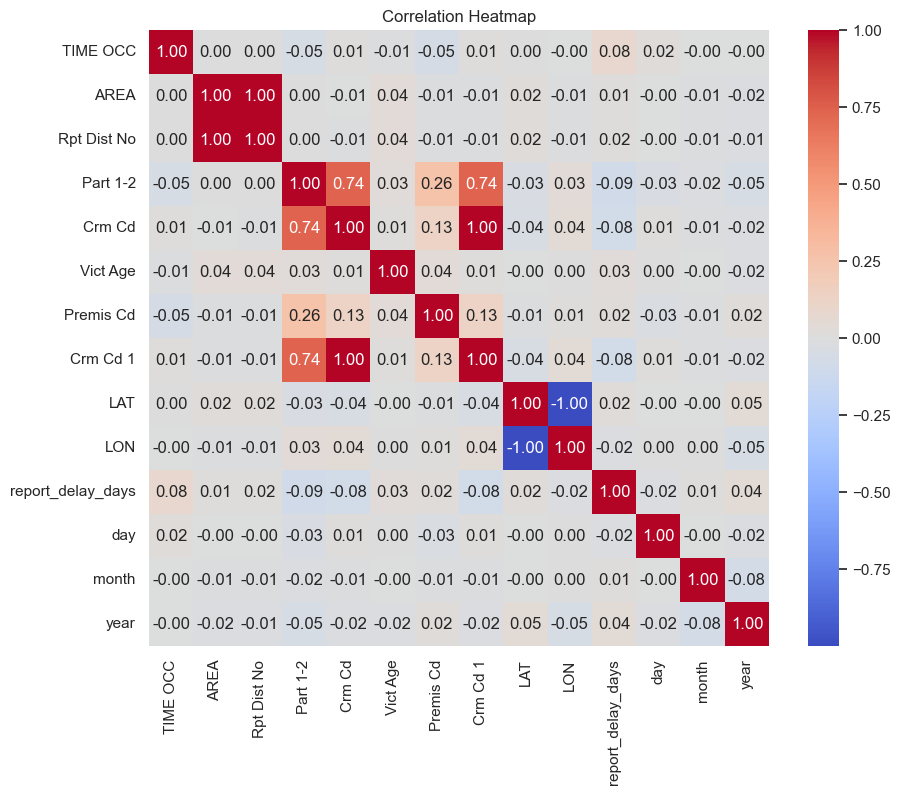

In [52]:
# correlation graph to see relationship between the different variables.

# Calculate correlation
corr = df.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

---

# ARIMA

In [53]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(crime_count_df['crime count'], order=(1,1,0))  # You can change order
results = model.fit()
print(results.summary())

                               SARIMAX Results                                
Dep. Variable:            crime count   No. Observations:                 1826
Model:                 ARIMA(1, 1, 0)   Log Likelihood               -9688.862
Date:                Mon, 18 Aug 2025   AIC                          19381.724
Time:                        17:01:27   BIC                          19392.743
Sample:                    01-01-2020   HQIC                         19385.789
                         - 12-30-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2125      0.016    -13.323      0.000      -0.244      -0.181
sigma2      2387.3846     39.526     60.400      0.000    2309.915    2464.855
Ljung-Box (L1) (Q):                   1.88   Jarque-

In [54]:
# Forecast the next 30 time points
forecast_steps = 30
forecast = results.forecast(steps=forecast_steps)

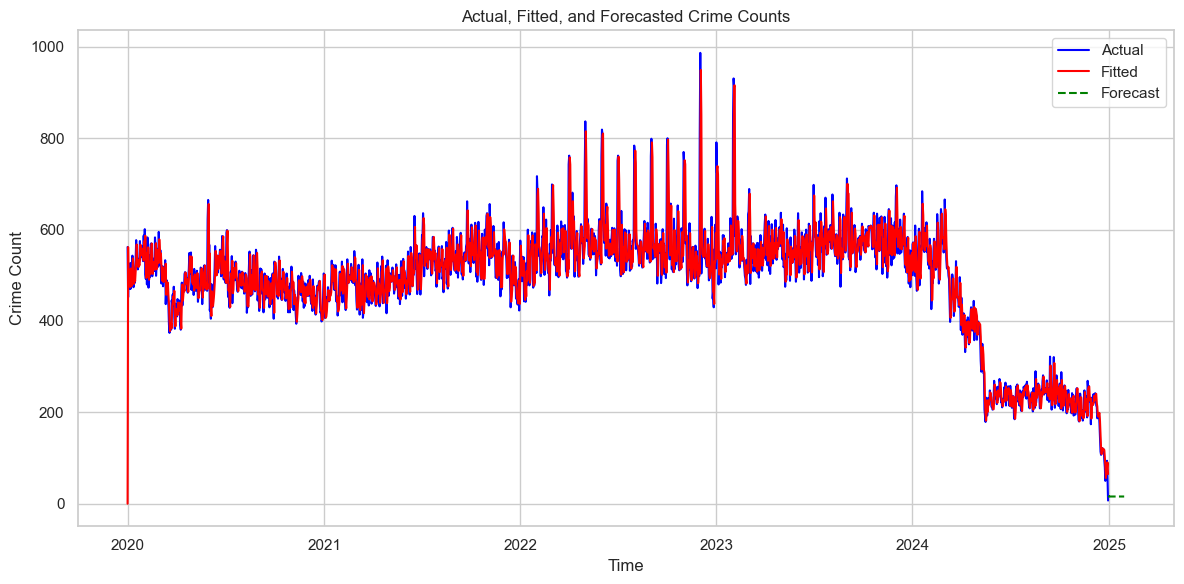

In [55]:
# Plot actual values
plt.figure(figsize=(12,6))
plt.plot(crime_count_df['crime count'], label='Actual', color='blue')

# Plot fitted values (in-sample predictions)
plt.plot(results.fittedvalues, label='Fitted', color='red')

# Plot forecasted values
forecast_index = pd.date_range(start=crime_count_df.index[-1] + pd.Timedelta(days=1), periods=forecast_steps, freq='D')
plt.plot(forecast_index, forecast, label='Forecast', color='green', linestyle='dashed')

# Plot styling
plt.title('Actual, Fitted, and Forecasted Crime Counts')
plt.xlabel('Time')
plt.ylabel('Crime Count')
plt.legend()
plt.tight_layout()
plt.show()

# SARIMA


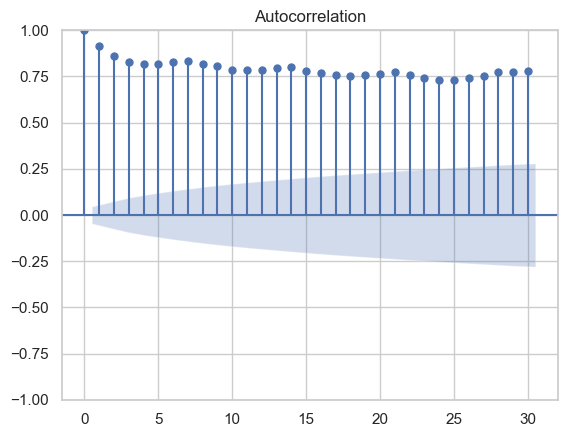

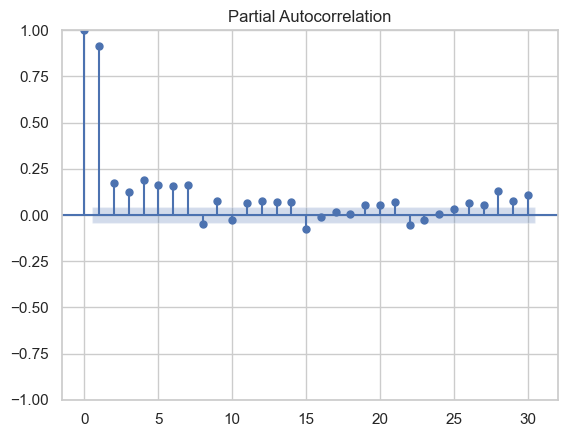

In [56]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(crime_count_df['crime count'], lags=30)
plot_pacf(crime_count_df['crime count'], lags=30)
plt.show()

In [57]:
from pmdarima import auto_arima
with warnings.catch_warnings():
    warnings.simplefilter("ignore")  # suppress all warnings in this block
    stepwise_model = auto_arima(crime_count_df['crime count'],
                                seasonal=True,
                                m=7,  # weekly seasonality
                                trace=True,
                                suppress_warnings=True)
    print(stepwise_model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[7] intercept   : AIC=inf, Time=4.84 sec
 ARIMA(0,1,0)(0,0,0)[7] intercept   : AIC=19465.815, Time=0.03 sec
 ARIMA(1,1,0)(1,0,0)[7] intercept   : AIC=19328.535, Time=0.50 sec
 ARIMA(0,1,1)(0,0,1)[7] intercept   : AIC=19280.434, Time=0.74 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=19463.882, Time=0.07 sec
 ARIMA(0,1,1)(0,0,0)[7] intercept   : AIC=19319.898, Time=0.31 sec
 ARIMA(0,1,1)(1,0,1)[7] intercept   : AIC=inf, Time=2.15 sec
 ARIMA(0,1,1)(0,0,2)[7] intercept   : AIC=19252.252, Time=1.42 sec
 ARIMA(0,1,1)(1,0,2)[7] intercept   : AIC=inf, Time=3.27 sec
 ARIMA(0,1,0)(0,0,2)[7] intercept   : AIC=19398.937, Time=0.93 sec
 ARIMA(1,1,1)(0,0,2)[7] intercept   : AIC=18994.852, Time=2.96 sec
 ARIMA(1,1,1)(0,0,1)[7] intercept   : AIC=19015.922, Time=1.61 sec
 ARIMA(1,1,1)(1,0,2)[7] intercept   : AIC=inf, Time=5.88 sec
 ARIMA(1,1,1)(1,0,1)[7] intercept   : AIC=inf, Time=3.62 sec
 ARIMA(1,1,0)(0,0,2)[7] intercept   : AIC=19313.8

In [58]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(crime_count_df['crime count'], order=(1, 1, 1), seasonal_order=(1, 1, 1, 7))
#model = SARIMAX(crime_count_df['crime count'], order=(3, 1, 1), seasonal_order=(0, 0, 2, 7))

results = model.fit()
print(results.summary())

                                     SARIMAX Results                                     
Dep. Variable:                       crime count   No. Observations:                 1826
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 7)   Log Likelihood               -9376.808
Date:                           Mon, 18 Aug 2025   AIC                          18763.616
Time:                                   17:03:21   BIC                          18791.143
Sample:                               01-01-2020   HQIC                         18773.772
                                    - 12-30-2024                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5109      0.018     28.474      0.000       0.476       0.546
ma.L1         -0.9335      0.012    -79.630

In [59]:
forecast = results.get_forecast(steps=30)
forecast_df = forecast.conf_int()
forecast_df['Prediction'] = forecast.predicted_mean

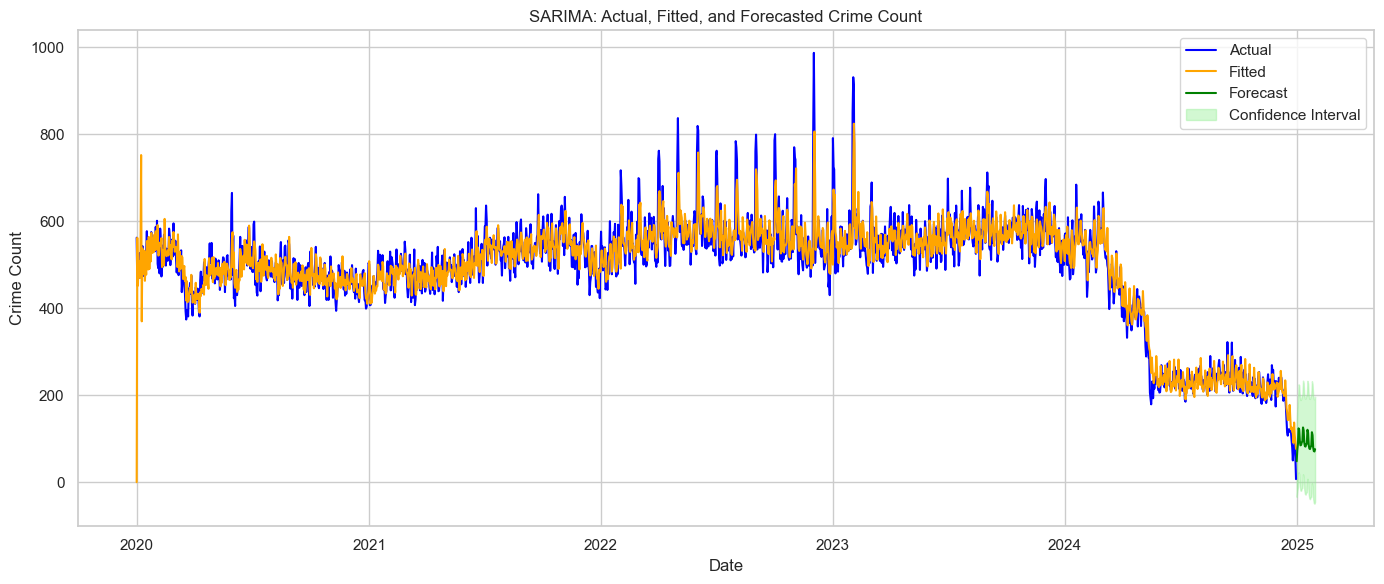

In [60]:
# Define the forecast index (dates)
forecast_index = pd.date_range(start=crime_count_df.index[-1] + pd.Timedelta(days=1), periods=30)

# Add index to forecast_df
forecast_df.index = forecast_index

# Plot actual data
plt.figure(figsize=(14, 6))
plt.plot(crime_count_df['crime count'], label='Actual', color='blue')

# Plot fitted values (in-sample predictions)
plt.plot(results.fittedvalues, label='Fitted', color='orange')

# Plot forecast
plt.plot(forecast_df['Prediction'], label='Forecast', color='green')

# Plot confidence intervals
plt.fill_between(forecast_df.index,
                 forecast_df['lower crime count'],
                 forecast_df['upper crime count'],
                 color='lightgreen', alpha=0.4, label='Confidence Interval')

# Final touches
plt.title('SARIMA: Actual, Fitted, and Forecasted Crime Count')
plt.xlabel('Date')
plt.ylabel('Crime Count')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# LSTM

In [61]:
df = pd.read_csv('crime_count_df.csv')
df['rime date'] = pd.to_datetime(df['crime date'])
df.set_index('crime date', inplace=True)
data = df[['crime count']]

In [62]:
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

In [63]:
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(seq_length, len(data)):
        X.append(data[i-seq_length:i])
        y.append(data[i])
    return np.array(X), np.array(y)

seq_length = 30
X, y = create_sequences(scaled_data, seq_length)

In [64]:
train_size = len(X) - 90
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [65]:
model = Sequential()
model.add(LSTM(64, return_sequences=False, input_shape=(X_train.shape[1], 1)))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mean_squared_error')

In [66]:
model.fit(X_train, y_train, epochs=40, batch_size=32, validation_data=(X_test, y_test), validation_split=0.1)


Epoch 1/40
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 0.0835 - val_loss: 0.0087
Epoch 2/40
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.0034 - val_loss: 0.0070
Epoch 3/40
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0031 - val_loss: 0.0053
Epoch 4/40
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0029 - val_loss: 0.0037
Epoch 5/40
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0032 - val_loss: 0.0026
Epoch 6/40
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0029 - val_loss: 0.0026
Epoch 7/40
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0032 - val_loss: 0.0018
Epoch 8/40
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0027 - val_loss: 0.0019
Epoch 9/40
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0028 - val_loss: 0.0018
Epoch 10/40
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0029 - val_loss: 0.0019
Epoch 11/40
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0033 - val_loss: 0.0017
Epoch 12/40
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0

In [67]:
predictions = model.predict(X_test)
predicted_crimes = scaler.inverse_transform(predictions)
actual_crimes = scaler.inverse_transform(y_test)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step


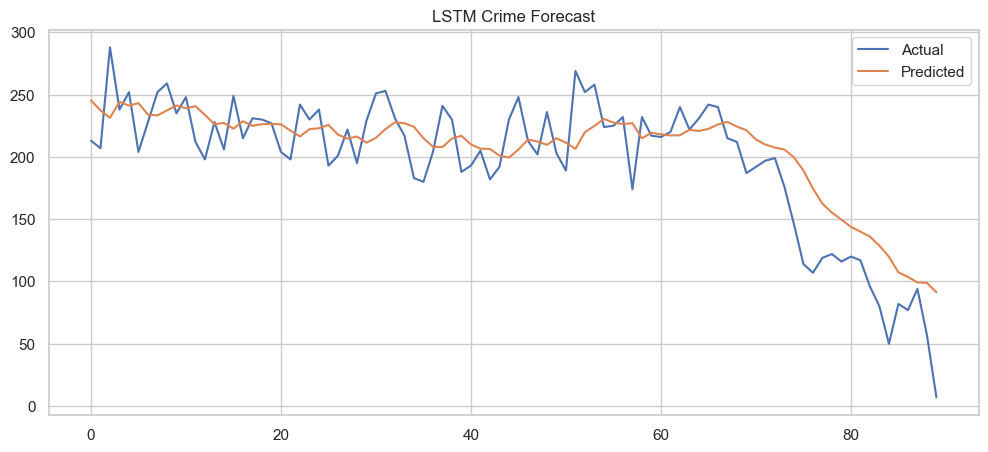

In [68]:
plt.figure(figsize=(12, 5))
plt.plot(actual_crimes, label='Actual')
plt.plot(predicted_crimes, label='Predicted')
plt.legend()
plt.title("LSTM Crime Forecast")
plt.show()


# Model Planning